# OPTIMIZED POWER RATING SYSTEM
### With Ridge Regression and Hyperparameter Optimization
1. Calculates team metrics from training data
2. Uses Ridge Regression with cross-validation
3. Optimizes calibration and process/results blend
4. Generates final rankings with optimized parameters
5. Validates model performance

In [89]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from scipy.optimize import minimize
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import optuna
from optuna.samplers import TPESampler

## 1. Load and Prepare Data

In [90]:
# Load data
df = pd.read_csv('whl_2025 - whl_2025.csv')
df = df[df['toi'] > 0].copy()
df['toi_min'] = df['toi'] / 60

print(f"Loaded {len(df)} records from {df['game_id'].nunique()} games")

Loaded 25827 records from 1312 games


In [91]:
# Create team perspective records
home_records = df[['game_id', 'record_id', 'home_team', 'away_team', 
                    'home_xg', 'away_xg', 'home_shots', 'away_shots',
                    'home_penalty_minutes', 'away_penalty_minutes',
                    'home_off_line', 'toi_min']].copy()
home_records.columns = ['game_id', 'record_id', 'team', 'opponent',
                        'team_xg', 'opponent_xg', 'team_shots', 'opponent_shots',
                        'team_pim', 'opponent_pim', 'offensive_line', 'toi_min']

away_records = df[['game_id', 'record_id', 'away_team', 'home_team',
                    'away_xg', 'home_xg', 'away_shots', 'home_shots',
                    'away_penalty_minutes', 'home_penalty_minutes',
                    'away_off_line', 'toi_min']].copy()
away_records.columns = ['game_id', 'record_id', 'team', 'opponent',
                        'team_xg', 'opponent_xg', 'team_shots', 'opponent_shots',
                        'team_pim', 'opponent_pim', 'offensive_line', 'toi_min']

team_on_ice = pd.concat([home_records, away_records], ignore_index=True)

## PIPELINE 1: Full Season Data (All Games)

In [92]:
# Using ALL SEASON DATA (no train/test split)
print("\nPIPELINE 1: FULL SEASON POWER RANKING")
print("Using: ALL games from entire season")

all_games_data = team_on_ice.copy()

# Remove empty net situations
print(f"  Before: {len(all_games_data)} records")
all_games_data = all_games_data[~all_games_data['offensive_line'].str.contains('empty_net', na=False)].copy()
print(f"  After: {len(all_games_data)} records")
print(f"  Removed {len(team_on_ice) - len(all_games_data)} empty net records")



PIPELINE 1: FULL SEASON POWER RANKING
Using: ALL games from entire season
  Before: 51654 records
  After: 49425 records
  Removed 2229 empty net records


In [93]:
# Calculate team metrics from ALL season data (Pipeline 1)
print("\nCalculating team metrics from ALL SEASON DATA...")

team_totals_all_season = all_games_data.groupby('team').agg({
    'team_xg': 'sum',
    'opponent_xg': 'sum',
    'team_shots': 'sum',
    'opponent_shots': 'sum',
    'team_pim': 'sum',
    'opponent_pim': 'sum',
    'toi_min': 'sum'
}).reset_index()

team_totals_all_season.columns = ['team', 'total_xg', 'total_xga', 'total_shots',
                       'total_shots_against', 'total_pim', 'total_opponent_pim',
                       'total_toi_min']

# Per-60 rates
team_totals_all_season['xGF_60'] = (team_totals_all_season['total_xg'] / team_totals_all_season['total_toi_min']) * 60
team_totals_all_season['xGA_60'] = (team_totals_all_season['total_xga'] / team_totals_all_season['total_toi_min']) * 60
team_totals_all_season['xGD_60'] = team_totals_all_season['xGF_60'] - team_totals_all_season['xGA_60']
team_totals_all_season['Shot_Diff_60'] = (team_totals_all_season['total_shots'] - team_totals_all_season['total_shots_against']) / team_totals_all_season['total_toi_min'] * 60

# Special Teams
pp_data = all_games_data[all_games_data['offensive_line'].str.contains('PP_up', na=False)]
if len(pp_data) > 0:
    pp_totals = pp_data.groupby('team').agg({'team_xg': 'sum', 'toi_min': 'sum'}).reset_index()
    pp_totals['PP_xGF_60'] = (pp_totals['team_xg'] / pp_totals['toi_min']) * 60
    team_totals_all_season = team_totals_all_season.merge(pp_totals[['team', 'PP_xGF_60']], on='team', how='left')
else:
    team_totals_all_season['PP_xGF_60'] = 0

pk_data = all_games_data[all_games_data['offensive_line'].str.contains('kill_dwn', na=False)]
if len(pk_data) > 0:
    pk_totals = pk_data.groupby('team').agg({'opponent_xg': 'sum', 'toi_min': 'sum'}).reset_index()
    pk_totals['PK_xGA_60'] = (pk_totals['opponent_xg'] / pk_totals['toi_min']) * 60
    team_totals_all_season = team_totals_all_season.merge(pk_totals[['team', 'PK_xGA_60']], on='team', how='left')
else:
    team_totals_all_season['PK_xGA_60'] = 0

team_totals_all_season['PP_xGF_60'] = team_totals_all_season['PP_xGF_60'].fillna(team_totals_all_season['PP_xGF_60'].mean())
team_totals_all_season['PK_xGA_60'] = team_totals_all_season['PK_xGA_60'].fillna(team_totals_all_season['PK_xGA_60'].mean())

# Line Depth
first_line = all_games_data[all_games_data['offensive_line'] == 'first_off'].groupby('team').agg({
    'team_xg': 'sum', 'toi_min': 'sum'}).reset_index()
first_line['first_xG_60'] = (first_line['team_xg'] / first_line['toi_min']) * 60

second_line = all_games_data[all_games_data['offensive_line'] == 'second_off'].groupby('team').agg({
    'team_xg': 'sum', 'toi_min': 'sum'}).reset_index()
second_line['second_xG_60'] = (second_line['team_xg'] / second_line['toi_min']) * 60

team_totals_all_season = team_totals_all_season.merge(first_line[['team', 'first_xG_60']], on='team', how='left')
team_totals_all_season = team_totals_all_season.merge(second_line[['team', 'second_xG_60']], on='team', how='left')

team_totals_all_season['first_xG_60'] = team_totals_all_season['first_xG_60'].fillna(team_totals_all_season['xGF_60'])
team_totals_all_season['second_xG_60'] = team_totals_all_season['second_xG_60'].fillna(team_totals_all_season['xGF_60'])
team_totals_all_season['Line_Depth'] = np.log((team_totals_all_season['first_xG_60'] + 0.1) / (team_totals_all_season['second_xG_60'] + 0.1))

print(f"✓ Calculated metrics for {len(team_totals_all_season)} teams")

# Normalize metrics for Pipeline 1
metrics_to_normalize = ['xGF_60', 'Shot_Diff_60', 'PP_xGF_60', 'PK_xGA_60', 'Line_Depth']

for metric in metrics_to_normalize:
    mean = team_totals_all_season[metric].mean()
    std = team_totals_all_season[metric].std()
    team_totals_all_season[f'z_{metric}'] = (team_totals_all_season[metric] - mean) / std

team_totals_all_season['z_PK_Success'] = -team_totals_all_season['z_PK_xGA_60']
team_totals_all_season['z_PP_Success'] = team_totals_all_season['z_PP_xGF_60']

print("✓ Normalized all metrics")

# Create interaction terms for Pipeline 1
interaction_pairs = [
    ('z_xGF_60', 'z_Shot_Diff_60'),
    ('z_xGF_60', 'z_PP_Success'),
    ('z_xGF_60', 'z_PK_Success'),
    ('z_Shot_Diff_60', 'z_PP_Success'),
    ('z_Shot_Diff_60', 'z_PK_Success'),
    ('z_PP_Success', 'z_PK_Success'),
]

for feat1, feat2 in interaction_pairs:
    interaction_name = f'{feat1}_x_{feat2}'
    team_totals_all_season[interaction_name] = team_totals_all_season[feat1] * team_totals_all_season[feat2]

print(f"✓ Created {len(interaction_pairs)} interaction terms")



Calculating team metrics from ALL SEASON DATA...
✓ Calculated metrics for 32 teams
✓ Normalized all metrics
✓ Created 6 interaction terms


In [94]:
# Calculate win percentage for all season data (Pipeline 1)
game_results_all = df.groupby('game_id').agg({
    'home_team': 'first',
    'away_team': 'first',
    'home_goals': 'sum',
    'away_goals': 'sum'
}).reset_index()

wins_dict_all = {}
total_dict_all = {}

for team in team_totals_all_season['team']:
    wins = 0
    total = 0
    for _, g in game_results_all.iterrows():
        if g['home_team'] == team:
            total += 1
            if g['home_goals'] > g['away_goals']:
                wins += 1
        elif g['away_team'] == team:
            total += 1
            if g['away_goals'] > g['home_goals']:
                wins += 1
    wins_dict_all[team] = wins
    total_dict_all[team] = total

team_totals_all_season['Wins'] = team_totals_all_season['team'].map(wins_dict_all)
team_totals_all_season['Total_Games'] = team_totals_all_season['team'].map(total_dict_all)
team_totals_all_season['Win_Pct'] = team_totals_all_season['Wins'] / team_totals_all_season['Total_Games']

# Train Ridge model on ALL season data (Pipeline 1)
feature_names = ['z_xGF_60', 'z_Shot_Diff_60', 'z_PP_Success', 'z_PK_Success', 'z_Line_Depth']
X_all_season = team_totals_all_season[feature_names].values
scaler_all_season = StandardScaler()
X_all_season_scaled = scaler_all_season.fit_transform(X_all_season)

# Use a standard Ridge alpha (no Bayesian optimization for Pipeline 1)
ridge_model_all_season = Ridge(alpha=1.0, random_state=42)
ridge_model_all_season.fit(X_all_season_scaled, team_totals_all_season['Win_Pct'].values)

team_totals_all_season['process_rating'] = ridge_model_all_season.predict(X_all_season_scaled)
team_totals_all_season['results_rating'] = (team_totals_all_season['Win_Pct'] - 0.5) / 0.15

# Weights will be optimized based on actual game data (calculated in next cell)
# Using placeholder values for now
process_weight_all = 0.85
results_weight_all = 1.0 - process_weight_all

team_totals_all_season['POWER_RATING'] = (
    process_weight_all * team_totals_all_season['process_rating'] + 
    results_weight_all * team_totals_all_season['results_rating']
)

print("\n✓ Ridge model trained and ratings calculated")
print("✓ Weights will be optimized in next cell based on actual game outcomes")




✓ Ridge model trained and ratings calculated
✓ Weights will be optimized in next cell based on actual game outcomes


In [95]:
# Optimize Process/Results weighting for Pipeline 1
print("\n" + "="*100)
print("OPTIMIZING PROCESS/RESULTS WEIGHTS FOR PIPELINE 1")
print("="*100)

from sklearn.linear_model import LogisticRegression

# Grid of weight combinations to test
process_weights = np.arange(0.50, 1.01, 0.05)
results_grid = []

for pw in process_weights:
    rw = 1.0 - pw
    
    # Create power ratings with this weight combination
    temp_ratings = team_totals_all_season.copy()
    temp_ratings['POWER_RATING'] = (
        pw * temp_ratings['process_rating'] + 
        rw * temp_ratings['results_rating']
    )
    
    # Create rating dictionary
    rating_dict_temp = dict(zip(temp_ratings['team'], temp_ratings['POWER_RATING']))
    
    # Test this combination against actual game results
    X_test = []
    y_test = []
    
    for _, game in game_results_all.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        
        home_rating = rating_dict_temp.get(home_team, 0)
        away_rating = rating_dict_temp.get(away_team, 0)
        rating_diff = home_rating - away_rating
        
        # Features: rating diff + home indicator
        X_test.append([rating_diff, 1])
        y_test.append(1 if game['home_goals'] > game['away_goals'] else 0)
    
    X_test = np.array(X_test)
    y_test = np.array(y_test)
    
    # Train logistic regression on this subset
    log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    log_reg.fit(X_test, y_test)
    
    # Get predictions and calculate metrics
    pred_probs = log_reg.predict_proba(X_test)[:, 1]
    predictions = pred_probs > 0.5
    
    accuracy = (predictions == y_test).mean()
    brier_score = brier_score_loss(y_test, pred_probs)
    
    results_grid.append({
        'process_weight': pw,
        'results_weight': rw,
        'accuracy': accuracy,
        'brier_score': brier_score
    })

results_df = pd.DataFrame(results_grid)

print(f"\nTesting {len(process_weights)} weight combinations:\n")
print(f"{'Process %':<15} {'Results %':<15} {'Accuracy':<15} {'Brier Score':<15}")
print("-"*70)

for _, row in results_df.iterrows():
    print(f"{row['process_weight']:.1%}{'':10} {row['results_weight']:.1%}{'':10} "
          f"{row['accuracy']:.4f}{'':10} {row['brier_score']:.4f}")

print("-"*70)

# Find best by Brier score (lower is better)
best_idx_brier = results_df['brier_score'].idxmin()
best_brier = results_df.loc[best_idx_brier]

# Find best by accuracy (higher is better)
best_idx_accuracy = results_df['accuracy'].idxmax()
best_accuracy = results_df.loc[best_idx_accuracy]

print(f"\n✓ Best by Brier Score:  {best_brier['process_weight']:.1%} process / {best_brier['results_weight']:.1%} results")
print(f"  Accuracy: {best_brier['accuracy']:.4f}, Brier: {best_brier['brier_score']:.4f}")

print(f"\n✓ Best by Accuracy:     {best_accuracy['process_weight']:.1%} process / {best_accuracy['results_weight']:.1%} results")
print(f"  Accuracy: {best_accuracy['accuracy']:.4f}, Brier: {best_accuracy['brier_score']:.4f}")

# Use Brier score as primary metric (more robust for probability calibration)
optimal_process_weight_p1 = best_brier['process_weight']
optimal_results_weight_p1 = best_brier['results_weight']

print(f"\n{'='*100}")
print(f"USING OPTIMAL WEIGHTS FOR PIPELINE 1:")
print(f"  Process Weight: {optimal_process_weight_p1:.1%}")
print(f"  Results Weight: {optimal_results_weight_p1:.1%}")
print(f"{'='*100}\n")



OPTIMIZING PROCESS/RESULTS WEIGHTS FOR PIPELINE 1

Testing 11 weight combinations:

Process %       Results %       Accuracy        Brier Score    
----------------------------------------------------------------------
50.0%           50.0%           0.6037           0.2324
55.0%           45.0%           0.6029           0.2324
60.0%           40.0%           0.6059           0.2324
65.0%           35.0%           0.6044           0.2325
70.0%           30.0%           0.6059           0.2326
75.0%           25.0%           0.6105           0.2328
80.0%           20.0%           0.6098           0.2330
85.0%           15.0%           0.6021           0.2335
90.0%           10.0%           0.5953           0.2344
95.0%           5.0%           0.5899           0.2362
100.0%           -0.0%           0.5861           0.2399
----------------------------------------------------------------------

✓ Best by Brier Score:  50.0% process / 50.0% results
  Accuracy: 0.6037, Brier: 0.2324

✓ B

In [96]:
# Recalculate rankings with optimized weights
team_totals_all_season['POWER_RATING'] = (
    optimal_process_weight_p1 * team_totals_all_season['process_rating'] + 
    optimal_results_weight_p1 * team_totals_all_season['results_rating']
)

# Create final rankings for Pipeline 1
rankings_all_season = team_totals_all_season.sort_values('POWER_RATING', ascending=False).reset_index(drop=True)
rankings_all_season['Rank'] = range(1, len(rankings_all_season) + 1)

print("\nPIPELINE 1 RESULTS (with optimized weights):")
print("="*100)
print(f"\n{'Rank':<6} {'Team':<15} {'Power Rating':<15} {'xGD/60':<12} {'Win%':<10} {'Record':<12}")
print("-"*100)

for _, row in rankings_all_season.iterrows():
    wins = int(row['Wins'])
    total = int(row['Total_Games'])
    losses = total - wins
    
    print(f"{row['Rank']:<6.0f} {row['team']:<15} {row['POWER_RATING']:>+13.4f}  "
          f"{row['xGD_60']:>+10.3f}  {row['Win_Pct']:>8.1%}  {wins:>2}-{losses:<2}")



PIPELINE 1 RESULTS (with optimized weights):

Rank   Team            Power Rating    xGD/60       Win%       Record      
----------------------------------------------------------------------------------------------------
1      brazil                +0.9900      +0.576     70.7%  58-24
2      netherlands           +0.8040      +0.406     65.9%  54-28
3      peru                  +0.7072      +0.252     63.4%  52-30
4      thailand              +0.6787      +0.785     61.0%  50-32
5      pakistan              +0.6104      +0.559     59.8%  49-33
6      india                 +0.5799      -0.025     59.8%  49-33
7      china                 +0.5104      +0.367     57.3%  47-35
8      iceland               +0.4608      -0.307     56.1%  46-36
9      panama                +0.4608      +0.074     56.1%  46-36
10     ethiopia              +0.3378      -0.341     52.4%  43-39
11     philippines           +0.3276      -0.318     52.4%  43-39
12     guatemala             +0.3052      +0.190  


AUC CURVE ANALYSIS - PIPELINE 1 MODEL EVALUATION (All Season Data)

All games set size: 1312 games
Home wins in all games: 740/1312 (56.4%)

✓ AUC-ROC Score:       0.6339
✓ PR-AUC Score:        0.6812
✓ Accuracy:            60.4%
✓ Brier Score:         0.2324


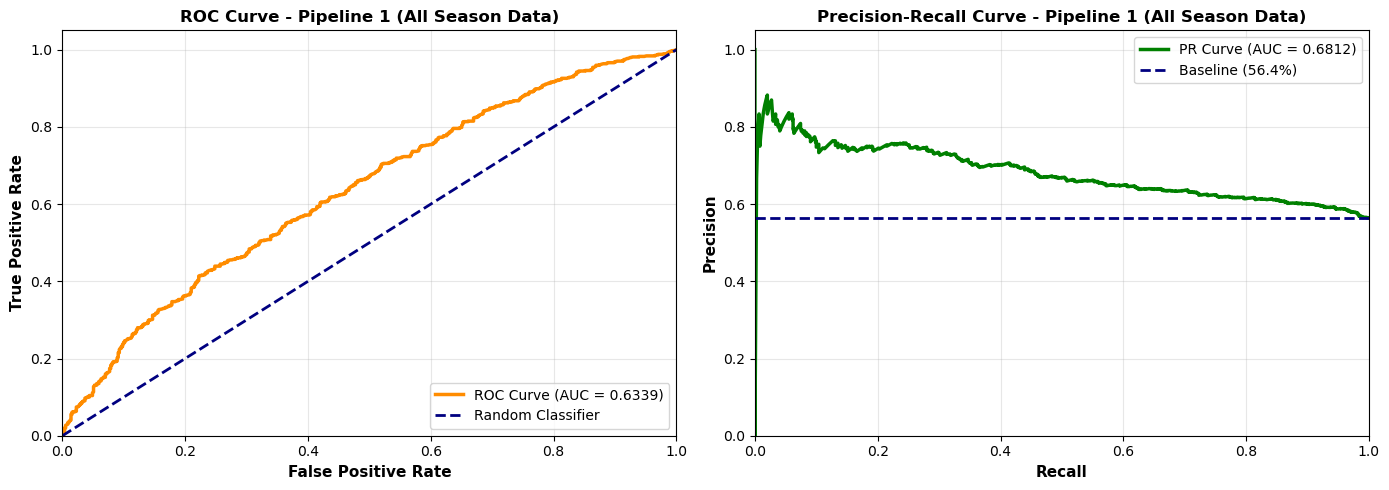


✓ Saved visualization: auc_curves_pipeline1.png

----------------------------------------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------------------------------------
  • ROC-AUC of 0.6339 indicates model discrimination ability on all season games
  • Perfect classifier = 1.0, Random classifier = 0.5
  • Precision-Recall AUC of 0.6812 shows performance identifying home team wins
  • Note: Training on all data means this is baseline performance, not true test set



In [98]:
# AUC Curve Analysis - Pipeline 1 Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

print("\n" + "="*100)
print("AUC CURVE ANALYSIS - PIPELINE 1 MODEL EVALUATION (All Season Data)")
print("="*100)

# Create game results from ALL games
all_game_results_p1 = df.groupby('game_id').agg({
    'home_team': 'first',
    'away_team': 'first',
    'home_goals': 'sum',
    'away_goals': 'sum'
}).reset_index()

# Create rating dictionary from Pipeline 1 rankings
rating_dict_p1 = dict(zip(rankings_all_season['team'], rankings_all_season['POWER_RATING']))

# Build logistic regression model for Pipeline 1 (using all games)
X_logistic_p1 = []
y_logistic_p1 = []

for _, game in all_game_results_p1.iterrows():
    home_team = game['home_team']
    away_team = game['away_team']
    
    # Get ratings
    home_rating = rating_dict_p1.get(home_team, 0)
    away_rating = rating_dict_p1.get(away_team, 0)
    
    # Feature 1: Rating difference (home perspective)
    rating_diff = home_rating - away_rating
    
    # Feature 2: Home indicator
    home_indicator = 1
    
    # Label: Did home team win?
    home_won = game['home_goals'] > game['away_goals']
    
    X_logistic_p1.append([rating_diff, home_indicator])
    y_logistic_p1.append(1 if home_won else 0)

X_logistic_p1 = np.array(X_logistic_p1)
y_logistic_p1 = np.array(y_logistic_p1)

print(f"\nAll games set size: {len(X_logistic_p1)} games")
print(f"Home wins in all games: {y_logistic_p1.sum()}/{len(y_logistic_p1)} ({y_logistic_p1.mean():.1%})")

# Fit logistic regression
from sklearn.linear_model import LogisticRegression

logistic_model_p1 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
logistic_model_p1.fit(X_logistic_p1, y_logistic_p1)

# Get predictions
y_pred_probs_p1 = logistic_model_p1.predict_proba(X_logistic_p1)[:, 1]
y_pred_binary_p1 = y_pred_probs_p1 > 0.5

# Calculate metrics
roc_auc_p1 = roc_auc_score(y_logistic_p1, y_pred_probs_p1)
logistic_accuracy_p1 = (y_pred_binary_p1 == y_logistic_p1).mean()
logistic_brier_p1 = brier_score_loss(y_logistic_p1, y_pred_probs_p1)

# Calculate ROC curve
fpr_p1, tpr_p1, _ = roc_curve(y_logistic_p1, y_pred_probs_p1)
roc_auc_curve_p1 = auc(fpr_p1, tpr_p1)

# Calculate precision-recall metrics
precision_p1, recall_p1, _ = precision_recall_curve(y_logistic_p1, y_pred_probs_p1)
pr_auc_p1 = average_precision_score(y_logistic_p1, y_pred_probs_p1)

print(f"\n✓ AUC-ROC Score:       {roc_auc_p1:.4f}")
print(f"✓ PR-AUC Score:        {pr_auc_p1:.4f}")
print(f"✓ Accuracy:            {logistic_accuracy_p1:.1%}")
print(f"✓ Brier Score:         {logistic_brier_p1:.4f}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr_p1, tpr_p1, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_p1:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - Pipeline 1 (All Season Data)', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(recall_p1, precision_p1, color='green', lw=2.5, label=f'PR Curve (AUC = {pr_auc_p1:.4f})')
axes[1].axhline(y=y_logistic_p1.mean(), color='navy', linestyle='--', lw=2, label=f'Baseline ({y_logistic_p1.mean():.1%})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision-Recall Curve - Pipeline 1 (All Season Data)', fontsize=12, fontweight='bold')
axes[1].legend(loc="best", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('auc_curves_pipeline1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization: auc_curves_pipeline1.png")

# Print interpretation
print("\n" + "-"*100)
print("INTERPRETATION:")
print("-"*100)
print(f"  • ROC-AUC of {roc_auc_p1:.4f} indicates model discrimination ability on all season games")
print(f"  • Perfect classifier = 1.0, Random classifier = 0.5")
print(f"  • Precision-Recall AUC of {pr_auc_p1:.4f} shows performance identifying home team wins")
print(f"  • Note: Training on all data means this is baseline performance, not true test set")
print("="*100 + "\n")

## 2. Pipeline 2: Train/Test Split

In [99]:
# Pipeline 2: Train/test split (85%/15%) for predicting future games
print("\nPIPELINE 2: TRAIN/TEST SPLIT FOR FUTURE GAME PREDICTIONS")
print("="*80)
print("Using: 85% training data to build model for predicting future games")
print("="*80)

unique_games = sorted(df['game_id'].unique())
n_games = len(unique_games)
train_cutoff = int(n_games * 0.85)
train_games_ids = set(unique_games[:train_cutoff])
test_games_ids = set(unique_games[train_cutoff:])  # Not used for ranking, only for reference

# Filter to train data
train_data = team_on_ice[team_on_ice['game_id'].isin(train_games_ids)].copy()

# Remove empty net situations (garbage time)
print("\nRemoving empty net situations...")
print(f"  Before: {len(train_data)} records")
train_data = train_data[~train_data['offensive_line'].str.contains('empty_net', na=False)].copy()
print(f"  After: {len(train_data)} records")
print(f"  ✓ Removed {len(team_on_ice[team_on_ice['game_id'].isin(train_games_ids)]) - len(train_data)} empty net records")


PIPELINE 2: TRAIN/TEST SPLIT FOR FUTURE GAME PREDICTIONS
Using: 85% training data to build model for predicting future games

Removing empty net situations...
  Before: 43850 records
  After: 41980 records
  ✓ Removed 1870 empty net records


In [100]:
# Calculate team metrics from TRAINING data only (Pipeline 2)
print("\nCalculating team metrics from 85% TRAINING DATA...")

team_totals = train_data.groupby('team').agg({
    'team_xg': 'sum',
    'opponent_xg': 'sum',
    'team_shots': 'sum',
    'opponent_shots': 'sum',
    'team_pim': 'sum',
    'opponent_pim': 'sum',
    'toi_min': 'sum'
}).reset_index()

team_totals.columns = ['team', 'total_xg', 'total_xga', 'total_shots',
                       'total_shots_against', 'total_pim', 'total_opponent_pim',
                       'total_toi_min']

# Per-60 rates
team_totals['xGF_60'] = (team_totals['total_xg'] / team_totals['total_toi_min']) * 60
team_totals['xGA_60'] = (team_totals['total_xga'] / team_totals['total_toi_min']) * 60
team_totals['xGD_60'] = team_totals['xGF_60'] - team_totals['xGA_60']
team_totals['Shot_Diff_60'] = (team_totals['total_shots'] - team_totals['total_shots_against']) / team_totals['total_toi_min'] * 60

# Special Teams
pp_data = train_data[train_data['offensive_line'].str.contains('PP_up', na=False)]
if len(pp_data) > 0:
    pp_totals = pp_data.groupby('team').agg({'team_xg': 'sum', 'toi_min': 'sum'}).reset_index()
    pp_totals['PP_xGF_60'] = (pp_totals['team_xg'] / pp_totals['toi_min']) * 60
    team_totals = team_totals.merge(pp_totals[['team', 'PP_xGF_60']], on='team', how='left')
else:
    team_totals['PP_xGF_60'] = 0

pk_data = train_data[train_data['offensive_line'].str.contains('kill_dwn', na=False)]
if len(pk_data) > 0:
    pk_totals = pk_data.groupby('team').agg({'opponent_xg': 'sum', 'toi_min': 'sum'}).reset_index()
    pk_totals['PK_xGA_60'] = (pk_totals['opponent_xg'] / pk_totals['toi_min']) * 60
    team_totals = team_totals.merge(pk_totals[['team', 'PK_xGA_60']], on='team', how='left')
else:
    team_totals['PK_xGA_60'] = 0

team_totals['PP_xGF_60'] = team_totals['PP_xGF_60'].fillna(team_totals['PP_xGF_60'].mean())
team_totals['PK_xGA_60'] = team_totals['PK_xGA_60'].fillna(team_totals['PK_xGA_60'].mean())

# Line Depth
first_line = train_data[train_data['offensive_line'] == 'first_off'].groupby('team').agg({
    'team_xg': 'sum', 'toi_min': 'sum'}).reset_index()
first_line['first_xG_60'] = (first_line['team_xg'] / first_line['toi_min']) * 60

second_line = train_data[train_data['offensive_line'] == 'second_off'].groupby('team').agg({
    'team_xg': 'sum', 'toi_min': 'sum'}).reset_index()
second_line['second_xG_60'] = (second_line['team_xg'] / second_line['toi_min']) * 60

team_totals = team_totals.merge(first_line[['team', 'first_xG_60']], on='team', how='left')
team_totals = team_totals.merge(second_line[['team', 'second_xG_60']], on='team', how='left')

team_totals['first_xG_60'] = team_totals['first_xG_60'].fillna(team_totals['xGF_60'])
team_totals['second_xG_60'] = team_totals['second_xG_60'].fillna(team_totals['xGF_60'])
team_totals['Line_Depth'] = np.log((team_totals['first_xG_60'] + 0.1) / (team_totals['second_xG_60'] + 0.1))

print(f"  ✓ Calculated metrics for {len(team_totals)} teams")



Calculating team metrics from 85% TRAINING DATA...
  ✓ Calculated metrics for 32 teams


In [101]:
# Normalize metrics from TRAINING data (Pipeline 2)
# Remove xGD_60 and xGA_60 to reduce multicollinearity (use xGF_60 + PK_xGA_60 instead)
metrics_to_normalize = ['xGF_60', 'Shot_Diff_60', 'PP_xGF_60', 'PK_xGA_60', 'Line_Depth']

for metric in metrics_to_normalize:
    mean = team_totals[metric].mean()
    std = team_totals[metric].std()
    team_totals[f'z_{metric}'] = (team_totals[metric] - mean) / std

# Transform PK/PP to "success" metrics (higher is better)
team_totals['z_PK_Success'] = -team_totals['z_PK_xGA_60']  # Lower xGA is better
team_totals['z_PP_Success'] = team_totals['z_PP_xGF_60']   # Higher xGF is better

print("✓ Normalized all metrics (removed redundant xGD_60/xGA_60)")
print(f"  Features used: xGF_60, Shot_Diff_60, PP_xGF_60, PK_xGA_60, Line_Depth")

# Create interaction terms between key metrics
print("\n✓ Creating interaction terms between key metrics...")
interaction_pairs = [
    ('z_xGF_60', 'z_Shot_Diff_60'),      # Offensive strength × Shot efficiency
    ('z_xGF_60', 'z_PP_Success'),         # Offensive strength × Power play
    ('z_xGF_60', 'z_PK_Success'),         # Offensive strength × Penalty kill
    ('z_Shot_Diff_60', 'z_PP_Success'),   # Shot differential × Power play
    ('z_Shot_Diff_60', 'z_PK_Success'),   # Shot differential × Penalty kill
    ('z_PP_Success', 'z_PK_Success'),     # Power play × Penalty kill (Special teams synergy)
]

for feat1, feat2 in interaction_pairs:
    interaction_name = f'{feat1}_x_{feat2}'
    team_totals[interaction_name] = team_totals[feat1] * team_totals[feat2]

print(f"  Added {len(interaction_pairs)} interaction terms:")
for feat1, feat2 in interaction_pairs:
    print(f"    • {feat1} × {feat2}")


✓ Normalized all metrics (removed redundant xGD_60/xGA_60)
  Features used: xGF_60, Shot_Diff_60, PP_xGF_60, PK_xGA_60, Line_Depth

✓ Creating interaction terms between key metrics...
  Added 6 interaction terms:
    • z_xGF_60 × z_Shot_Diff_60
    • z_xGF_60 × z_PP_Success
    • z_xGF_60 × z_PK_Success
    • z_Shot_Diff_60 × z_PP_Success
    • z_Shot_Diff_60 × z_PK_Success
    • z_PP_Success × z_PK_Success


## 3. Ridge Regression Optimization (Pipeline 2)

In [102]:
def bayesian_hyperparameter_optimization(team_metrics, test_games_ids, all_games_df, n_trials=50):

    feature_names = [
        'z_xGF_60', 'z_Shot_Diff_60',
        'z_PP_Success', 'z_PK_Success', 'z_Line_Depth'
    ]
    
    # Prepare data
    X = team_metrics[feature_names].values
    
    # Calculate Win_Pct from games if not already done
    game_results = all_games_df.groupby('game_id').agg({
        'home_team': 'first',
        'away_team': 'first',
        'home_goals': 'sum',
        'away_goals': 'sum'
    }).reset_index()
    
    wins_dict = {}
    total_dict = {}
    for team in team_metrics['team']:
        wins = 0
        total = 0
        for _, g in game_results.iterrows():
            if g['home_team'] == team:
                total += 1
                if g['home_goals'] > g['away_goals']:
                    wins += 1
            elif g['away_team'] == team:
                total += 1
                if g['away_goals'] > g['home_goals']:
                    wins += 1
        wins_dict[team] = wins
        total_dict[team] = total
    
    win_pct = []
    for team in team_metrics['team']:
        if total_dict[team] > 0:
            win_pct.append(wins_dict[team] / total_dict[team])
        else:
            win_pct.append(0.5)
    y = np.array(win_pct)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    test_games = game_results[game_results['game_id'].isin(test_games_ids)].copy()
    
    def objective(trial):
        # Suggest hyperparameters (alpha and calibration only)
        alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
        calibration = trial.suggest_float('calibration', 0.20, 1.00)  
        
        # Train Ridge model
        model = Ridge(alpha=alpha, random_state=42)
        kfold = KFold(n_splits=min(5, len(X)), shuffle=False)
        
        # Cross-validation score
        cv_scores = []
        for train_idx, val_idx in kfold.split(X_scaled):
            X_train = X_scaled[train_idx]
            y_train = y[train_idx]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_scaled[val_idx])
            mse = np.mean((y[val_idx] - y_pred) ** 2)
            cv_scores.append(mse)
        
        # Train on full data
        model.fit(X_scaled, y)
        process_rating = model.predict(X_scaled)
        
        # Use mid-range process_weight for Bayesian optimization
        # (will be fine-tuned separately via logistic regression)
        process_weight = 0.80
        results_weight = 1.0 - process_weight
        
        # Create temp dataframe for ratings
        temp_df = team_metrics.copy()
        temp_df['process_rating'] = process_rating
        temp_df['win_pct_temp'] = y
        temp_df['results_rating'] = (temp_df['win_pct_temp'] - 0.5) / 0.15
        temp_df['rating'] = (
            process_weight * temp_df['process_rating'] +
            results_weight * temp_df['results_rating']
        )
        
        rating_dict = dict(zip(temp_df['team'], temp_df['rating']))
        
        # Test on test set
        actuals = []
        predictions = []
        for _, game in test_games.iterrows():
            home_rating = rating_dict.get(game['home_team'], 0)
            away_rating = rating_dict.get(game['away_team'], 0)
            diff = home_rating - away_rating
            try:
                pred_prob = 1 / (1 + np.exp(-diff * calibration))
            except:
                pred_prob = 0.5
            
            actuals.append(1 if game['home_goals'] > game['away_goals'] else 0)
            predictions.append(pred_prob)
        
        brier = brier_score_loss(actuals, predictions)
        return brier
    
    print("="*80)
    print("BAYESIAN HYPERPARAMETER OPTIMIZATION (Optuna TPE Sampler)")
    print("Optimizing: Ridge Alpha, Calibration Coefficient")
    print("="*80)
    print(f"\nRunning {n_trials} trials...\n")
    
    sampler = TPESampler(seed=42, n_startup_trials=10)
    study = optuna.create_study(sampler=sampler, direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    best_params = study.best_params
    best_value = study.best_value
    
    print("\n" + "="*80)
    print("OPTIMIZATION COMPLETE (ALPHA & CALIBRATION)")
    print("="*80)
    print(f"\nBest Hyperparameters Found:")
    print(f"  Ridge Alpha:         {best_params['alpha']:.6f}")
    print(f"  Calibration Coeff:   {best_params['calibration']:.6f}")
    print(f"\nTop 5 Trials:")
    print(f"{'Trial':<6} {'Alpha':<12} {'Calibration':<12} {'Brier':<10}")
    print("-"*70)
    
    sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else float('inf'))
    for trial in sorted_trials[:5]:
        print(f"{trial.number:<6} {trial.params['alpha']:<12.6f} "
              f"{trial.params['calibration']:<12.6f} "
              f"{trial.value:<10.4f}")
    
    # ========================================================================
    # GRID SEARCH: Optimize process_weight via logistic regression
    # ========================================================================
    print("\n" + "="*80)
    print("OPTIMIZING PROCESS_WEIGHT VIA LOGISTIC REGRESSION")
    print("="*80)
    
    from sklearn.linear_model import LogisticRegression
    
    alpha_opt = best_params['alpha']
    calibration_opt = best_params['calibration']
    
    # Train Ridge model with optimal alpha
    ridge_model = Ridge(alpha=alpha_opt, random_state=42)
    ridge_model.fit(X_scaled, y)
    process_rating = ridge_model.predict(X_scaled)
    
    # Grid of process_weight values to test
    process_weights = np.arange(0.50, 1.00, 0.05)
    
    results_grid = []
    
    # Get train/test split info
    unique_games = sorted(game_results['game_id'].unique())
    n_games = len(unique_games)
    train_cutoff = int(n_games * 0.65)
    train_games_ids_local = set(unique_games[:train_cutoff])
    
    for pw in process_weights:
        rw = 1.0 - pw
        
        # Create ratings with this process_weight
        temp_df = team_metrics.copy()
        temp_df['process_rating'] = process_rating
        temp_df['win_pct_temp'] = y
        temp_df['results_rating'] = (temp_df['win_pct_temp'] - 0.5) / 0.15
        temp_df['rating'] = (pw * temp_df['process_rating'] + rw * temp_df['results_rating'])
        
        rating_dict = dict(zip(temp_df['team'], temp_df['rating']))
        
        # Get training games
        train_games = game_results[game_results['game_id'].isin(train_games_ids_local)].copy()
        
        X_log = []
        y_log = []
        
        for _, game in train_games.iterrows():
            home_rating = rating_dict.get(game['home_team'], 0)
            away_rating = rating_dict.get(game['away_team'], 0)
            rating_diff = home_rating - away_rating
            X_log.append([rating_diff, 1])
            y_log.append(1 if game['home_goals'] > game['away_goals'] else 0)
        
        X_log = np.array(X_log)
        y_log = np.array(y_log)
        
        # Train logistic regression
        log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
        log_reg.fit(X_log, y_log)
        
        # Test on test set
        actuals_test = []
        predictions_test = []
        
        for _, game in test_games.iterrows():
            home_rating = rating_dict.get(game['home_team'], 0)
            away_rating = rating_dict.get(game['away_team'], 0)
            rating_diff = home_rating - away_rating
            X_test_game = np.array([[rating_diff, 1]])
            pred_prob = log_reg.predict_proba(X_test_game)[0, 1]
            
            actuals_test.append(1 if game['home_goals'] > game['away_goals'] else 0)
            predictions_test.append(pred_prob)
        
        accuracy = ((np.array(predictions_test) > 0.5) == np.array(actuals_test)).mean()
        brier_score = brier_score_loss(actuals_test, predictions_test)
        
        results_grid.append({
            'process_weight': pw,
            'results_weight': rw,
            'accuracy': accuracy,
            'brier': brier_score,
            'log_coef_intercept': log_reg.intercept_[0],
            'log_coef_rating': log_reg.coef_[0][0],
            'log_coef_home': log_reg.coef_[0][1]
        })
    
    results_df = pd.DataFrame(results_grid)
    
    # Find best by accuracy
    best_idx_accuracy = results_df['accuracy'].idxmax()
    best_pw_accuracy = results_df.loc[best_idx_accuracy]
    
    # Find best by Brier
    best_idx_brier = results_df['brier'].idxmin()
    best_pw_brier = results_df.loc[best_idx_brier]
    
    print(f"\nGrid Search Results (Testing {len(process_weights)} process_weight values):\n")
    print(f"{'Process%':<12} {'Results%':<12} {'Accuracy':<12} {'Brier':<12}")
    print("-"*70)
    
    for _, row in results_df.iterrows():
        print(f"{row['process_weight']:.1%}{'':7} {row['results_weight']:.1%}{'':7} "
              f"{row['accuracy']:.4f}{'':6} {row['brier']:.4f}")
    
    print("-"*70)
    print(f"\n✓ Best by Accuracy:  {best_pw_accuracy['process_weight']:.1%} "
          f"(acc={best_pw_accuracy['accuracy']:.4f}, brier={best_pw_accuracy['brier']:.4f})")
    print(f"✓ Best by Brier:     {best_pw_brier['process_weight']:.1%} "
          f"(acc={best_pw_brier['accuracy']:.4f}, brier={best_pw_brier['brier']:.4f})")
    
    # Use best by accuracy as final choice
    best_process_weight = best_pw_accuracy['process_weight']
    
    # Store all params
    best_params['alpha'] = alpha_opt
    best_params['calibration'] = calibration_opt
    best_params['process_weight'] = best_process_weight
    
    print(f"\n{'='*80}")
    print(f"FINAL OPTIMIZED HYPERPARAMETERS:")
    print(f"{'='*80}")
    print(f"  Ridge Alpha:         {best_params['alpha']:.6f}")
    print(f"  Calibration Coeff:   {best_params['calibration']:.6f}")
    print(f"  Process Weight:      {best_params['process_weight']:.4f}")
    print(f"  Results Weight:      {1.0 - best_params['process_weight']:.4f}")
    print(f"{'='*80}\n")
    
    return best_params

# Run Bayesian optimization (alpha & calibration) + grid search (process_weight)
best_hyperparams = bayesian_hyperparameter_optimization(team_totals, test_games_ids, df, n_trials=50)

[I 2026-02-26 13:53:38,502] A new study created in memory with name: no-name-848f9b6d-e470-467b-9aa7-dc377d001830
[I 2026-02-26 13:53:38,508] Trial 0 finished with value: 0.2434740691591686 and parameters: {'alpha': 0.0745934328572655, 'calibration': 0.960571445127933}. Best is trial 0 with value: 0.2434740691591686.
[I 2026-02-26 13:53:38,513] Trial 1 finished with value: 0.24492379670622344 and parameters: {'alpha': 4.5705630998014515, 'calibration': 0.6789267873576292}. Best is trial 0 with value: 0.2434740691591686.
[I 2026-02-26 13:53:38,519] Trial 2 finished with value: 0.24714291287769644 and parameters: {'alpha': 0.006026889128682512, 'calibration': 0.32479561626896214}. Best is trial 0 with value: 0.2434740691591686.
[I 2026-02-26 13:53:38,524] Trial 3 finished with value: 0.243742339291058 and parameters: {'alpha': 0.0019517224641449498, 'calibration': 0.8929409166199482}. Best is trial 0 with value: 0.2434740691591686.
[I 2026-02-26 13:53:38,530] Trial 4 finished with value:

BAYESIAN HYPERPARAMETER OPTIMIZATION (Optuna TPE Sampler)
Optimizing: Ridge Alpha, Calibration Coefficient

Running 50 trials...



[I 2026-02-26 13:53:38,704] Trial 34 finished with value: 0.24507989621551632 and parameters: {'alpha': 0.06682272334342204, 'calibration': 0.6279035886597432}. Best is trial 29 with value: 0.24333147936713806.
[I 2026-02-26 13:53:38,710] Trial 35 finished with value: 0.2436670889554427 and parameters: {'alpha': 0.016336951584614748, 'calibration': 0.9111687431340562}. Best is trial 29 with value: 0.24333147936713806.
[I 2026-02-26 13:53:38,715] Trial 36 finished with value: 0.2433684657884331 and parameters: {'alpha': 0.005104123901692679, 'calibration': 0.9881067539186386}. Best is trial 29 with value: 0.24333147936713806.
[I 2026-02-26 13:53:38,721] Trial 37 finished with value: 0.2435432242156308 and parameters: {'alpha': 0.8696728890788674, 'calibration': 0.9508126727400223}. Best is trial 29 with value: 0.24333147936713806.
[I 2026-02-26 13:53:38,726] Trial 38 finished with value: 0.24441263612334088 and parameters: {'alpha': 1.7797346685095308, 'calibration': 0.7625133366947939}


OPTIMIZATION COMPLETE (ALPHA & CALIBRATION)

Best Hyperparameters Found:
  Ridge Alpha:         0.080144
  Calibration Coeff:   0.999241

Top 5 Trials:
Trial  Alpha        Calibration  Brier     
----------------------------------------------------------------------
29     0.080144     0.999241     0.2433    
45     0.046945     0.997911     0.2433    
22     0.018896     0.996610     0.2433    
31     0.085475     0.997139     0.2433    
41     0.024390     0.995289     0.2433    

OPTIMIZING PROCESS_WEIGHT VIA LOGISTIC REGRESSION

Grid Search Results (Testing 10 process_weight values):

Process%     Results%     Accuracy     Brier       
----------------------------------------------------------------------
50.0%        50.0%        0.6091       0.2347
55.0%        45.0%        0.6091       0.2348
60.0%        40.0%        0.6091       0.2349
65.0%        35.0%        0.6091       0.2350
70.0%        30.0%        0.6091       0.2351
75.0%        25.0%        0.6091       0.2354
80.0

In [103]:
# Create final rankings with optimized hyperparameters (Pipeline 2)
print("\n" + "="*100)
print("CREATING FINAL RANKINGS WITH OPTIMIZED HYPERPARAMETERS (Pipeline 2)")
print("="*100)

# Re-train Ridge model with optimal alpha on training data
feature_names = ['z_xGF_60', 'z_Shot_Diff_60', 'z_PP_Success', 'z_PK_Success', 'z_Line_Depth']
X_train = team_totals[feature_names].values
scaler_train = StandardScaler()
X_train_scaled = scaler_train.fit_transform(X_train)

# Calculate win percentage from all games for these teams
game_results_all = df.groupby('game_id').agg({
    'home_team': 'first',
    'away_team': 'first',
    'home_goals': 'sum',
    'away_goals': 'sum'
}).reset_index()

wins_dict = {}
total_dict = {}
for team in team_totals['team']:
    wins = 0
    total = 0
    for _, g in game_results_all.iterrows():
        if g['home_team'] == team:
            total += 1
            if g['home_goals'] > g['away_goals']:
                wins += 1
        elif g['away_team'] == team:
            total += 1
            if g['away_goals'] > g['home_goals']:
                wins += 1
    wins_dict[team] = wins
    total_dict[team] = total

team_totals['Wins'] = team_totals['team'].map(wins_dict)
team_totals['Total_Games'] = team_totals['team'].map(total_dict)
team_totals['Win_Pct'] = team_totals['Wins'] / team_totals['Total_Games']

# Train Ridge model with optimal alpha
ridge_model = Ridge(alpha=best_hyperparams['alpha'], random_state=42)
ridge_model.fit(X_train_scaled, team_totals['Win_Pct'].values)

# Calculate process and results ratings
team_totals['process_rating'] = ridge_model.predict(X_train_scaled)
team_totals['results_rating'] = (team_totals['Win_Pct'] - 0.5) / 0.15

# Apply optimal weights
optimal_process_weight = best_hyperparams['process_weight']
optimal_results_weight = 1.0 - optimal_process_weight

team_totals['POWER_RATING'] = (
    optimal_process_weight * team_totals['process_rating'] + 
    optimal_results_weight * team_totals['results_rating']
)

# Create final rankings
rankings = team_totals.sort_values('POWER_RATING', ascending=False).reset_index(drop=True)
rankings['Rank'] = range(1, len(rankings) + 1)

print(f"\n✓ Created rankings for {len(rankings)} teams")
print(f"  Ridge Alpha: {best_hyperparams['alpha']:.6f}")
print(f"  Process Weight: {optimal_process_weight:.1%}")
print(f"  Results Weight: {optimal_results_weight:.1%}\n")

print(f"{'Rank':<6} {'Team':<15} {'Power Rating':<15} {'xGD/60':<12} {'Win%':<10} {'Record':<12}")
print("-"*100)
for _, row in rankings.head(10).iterrows():
    wins = int(row['Wins'])
    total = int(row['Total_Games'])
    losses = total - wins
    print(f"{row['Rank']:<6.0f} {row['team']:<15} {row['POWER_RATING']:>+13.4f}  "
          f"{row['xGD_60']:>+10.3f}  {row['Win_Pct']:>8.1%}  {wins:>2}-{losses:<2}")



CREATING FINAL RANKINGS WITH OPTIMIZED HYPERPARAMETERS (Pipeline 2)

✓ Created rankings for 32 teams
  Ridge Alpha: 0.080144
  Process Weight: 80.0%
  Results Weight: 20.0%

Rank   Team            Power Rating    xGD/60       Win%       Record      
----------------------------------------------------------------------------------------------------
1      brazil                +0.7698      +0.562     70.7%  58-24
2      netherlands           +0.6673      +0.468     65.9%  54-28
3      thailand              +0.6367      +0.656     61.0%  50-32
4      peru                  +0.5857      +0.189     63.4%  52-30
5      pakistan              +0.5782      +0.535     59.8%  49-33
6      india                 +0.5314      +0.006     59.8%  49-33
7      china                 +0.5304      +0.302     57.3%  47-35
8      panama                +0.5153      +0.135     56.1%  46-36
9      iceland               +0.4945      -0.352     56.1%  46-36
10     serbia                +0.4516      +0.136     5

## 4. Predict Future Games (Pipeline 2)

In [104]:
# Prepare data for game predictions (Pipeline 2)
# Use Pipeline 2 rankings for predictions
rank_dict = dict(zip(rankings['team'], rankings['Rank']))
rating_dict = dict(zip(rankings['team'], rankings['POWER_RATING']))

# Create game_results from all games
all_game_results = df.groupby('game_id').agg({
    'home_team': 'first',
    'away_team': 'first',
    'home_goals': 'sum',
    'away_goals': 'sum'
}).reset_index()

# Separate training and test games
game_results = all_game_results[all_game_results['game_id'].isin(train_games_ids)].copy()
test_game_results = all_game_results[all_game_results['game_id'].isin(test_games_ids)].copy()

# Add ratings to training games
game_results['home_rank'] = game_results['home_team'].map(rank_dict)
game_results['away_rank'] = game_results['away_team'].map(rank_dict)
game_results['home_rating'] = game_results['home_team'].map(rating_dict)
game_results['away_rating'] = game_results['away_team'].map(rating_dict)
game_results['home_won'] = game_results['home_goals'] > game_results['away_goals']

# Add ratings to test games
test_game_results['home_rank'] = test_game_results['home_team'].map(rank_dict)
test_game_results['away_rank'] = test_game_results['away_team'].map(rank_dict)
test_game_results['home_rating'] = test_game_results['home_team'].map(rating_dict)
test_game_results['away_rating'] = test_game_results['away_team'].map(rating_dict)
test_game_results['home_won'] = test_game_results['home_goals'] > test_game_results['away_goals']



In [105]:
print("\n" + "="*100)
print("IMPROVEMENT #2: Adding Goaltending & Shooting Performance")
print("="*100)

def calculate_goalie_and_shooting_metrics(df, game_results_df, training_game_ids):
    """
    Calculate actual performance vs expected (PDO components)
    """
    # Filter game results to only training games
    training_games = game_results_df[game_results_df['game_id'].isin(training_game_ids)].copy()
    
    team_stats = []
    
    for team in df['team'].unique():
        team_data = df[df['team'] == team]
        
        # Total TOI
        total_toi = team_data['toi_min'].sum()
        
        # Expected vs Actual
        total_xgf = team_data['team_xg'].sum()
        total_xga = team_data['opponent_xg'].sum()
        
        # Count actual goals from game results
        goals_for = 0
        goals_against = 0
        
        # Count actual goals from training games only
        for _, game in training_games.iterrows():
            if game['home_team'] == team:
                goals_for += game['home_goals']
                goals_against += game['away_goals']
            elif game['away_team'] == team:
                goals_for += game['away_goals']
                goals_against += game['home_goals']
        
        # Goals above/below expected (per 60)
        if total_toi > 0:
            GSAE_60 = ((total_xga - goals_against) / total_toi) * 60  # Goals saved above expected
            GAE_60 = ((goals_for - total_xgf) / total_toi) * 60        # Goals above expected (shooting)
            PDO = (goals_for / total_xgf) + ((total_xga - goals_against) / total_xga) if total_xgf > 0 and total_xga > 0 else 1.0
        else:
            GSAE_60 = 0
            GAE_60 = 0
            PDO = 1.0
        
        team_stats.append({
            'team': team,
            'GSAE_60': GSAE_60,      # Goalie performance (positive = better than expected)
            'GAE_60': GAE_60,         # Shooting performance (positive = better than expected)
            'PDO': PDO,               # Combined luck/skill metric
            'actual_GF': goals_for,
            'expected_GF': total_xgf,
            'actual_GA': goals_against,
            'expected_GA': total_xga
        })
    
    return pd.DataFrame(team_stats)

# Calculate goalie and shooting metrics
print("\nCalculating goaltending and shooting performance...")
perf_metrics = calculate_goalie_and_shooting_metrics(train_data, all_game_results, train_games_ids)

# Merge with team_totals
team_totals = team_totals.merge(perf_metrics[['team', 'GSAE_60', 'GAE_60', 'PDO']], on='team', how='left')

# Normalize
team_totals['z_GSAE_60'] = (team_totals['GSAE_60'] - team_totals['GSAE_60'].mean()) / team_totals['GSAE_60'].std()
team_totals['z_GAE_60'] = (team_totals['GAE_60'] - team_totals['GAE_60'].mean()) / team_totals['GAE_60'].std()
team_totals['z_PDO'] = (team_totals['PDO'] - team_totals['PDO'].mean()) / team_totals['PDO'].std()

print(f"\n✓ Added goaltending and shooting metrics:")
print(f"  • GSAE_60: Goals Saved Above Expected per 60 (goalie performance)")
print(f"  • GAE_60: Goals Above Expected per 60 (shooting performance)")
print(f"  • PDO: Combined metric (league average ≈ 1.0)")

# Show top/bottom teams
print(f"\nTop 5 Goaltending:")
print(team_totals.nlargest(5, 'GSAE_60')[['team', 'GSAE_60']])
print(f"\nTop 5 Shooting:")
print(team_totals.nlargest(5, 'GAE_60')[['team', 'GAE_60']])


IMPROVEMENT #2: Adding Goaltending & Shooting Performance

Calculating goaltending and shooting performance...

✓ Added goaltending and shooting metrics:
  • GSAE_60: Goals Saved Above Expected per 60 (goalie performance)
  • GAE_60: Goals Above Expected per 60 (shooting performance)
  • PDO: Combined metric (league average ≈ 1.0)

Top 5 Goaltending:
           team   GSAE_60
8         india  0.587628
20  philippines  0.543345
7       iceland  0.498851
0        brazil  0.456144
19         peru  0.428069

Top 5 Shooting:
           team    GAE_60
3      ethiopia  0.412123
25  south_korea  0.409886
5       germany  0.311605
13      morocco  0.254942
7       iceland  0.215611


In [106]:
print("\n" + "="*100)
print("LEARNING HOME ADVANTAGE VIA LOGISTIC REGRESSION")
print("="*100)
print("\nFitting logistic regression: P = 1 / (1 + e^(-β₀ - β₁*rating_diff - β₂*home))")

# Prepare training data: home and away games from training set
train_games_list = game_results[game_results['game_id'].isin(train_games_ids)].copy()

# Create features for logistic regression
X_logistic = []
y_logistic = []

for _, game in train_games_list.iterrows():
    home_team = game['home_team']
    away_team = game['away_team']
    
    # Get ratings
    home_rating = rating_dict.get(home_team, 0)
    away_rating = rating_dict.get(away_team, 0)
    
    # Feature 1: Rating difference (home perspective)
    rating_diff = home_rating - away_rating
    
    # Feature 2: Home indicator
    home_indicator = 1
    
    # Label: Did home team win?
    home_won = game['home_goals'] > game['away_goals']
    
    X_logistic.append([rating_diff, home_indicator])
    y_logistic.append(1 if home_won else 0)

X_logistic = np.array(X_logistic)
y_logistic = np.array(y_logistic)

print(f"\nTraining set size: {len(X_logistic)} games")
print(f"Home wins in training set: {y_logistic.sum()}/{len(y_logistic)} ({y_logistic.mean():.1%})")

# Fit logistic regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
logistic_model.fit(X_logistic, y_logistic)

# Extract coefficients
intercept = logistic_model.intercept_[0]
beta_rating_diff = logistic_model.coef_[0][0]
beta_home = logistic_model.coef_[0][1]

print(f"\n" + "-"*100)
print("LEARNED PARAMETERS:")
print("-"*100)
print(f"  β₀ (Intercept):        {intercept:+.6f}")
print(f"  β₁ (Rating Diff):      {beta_rating_diff:+.6f}")
print(f"  β₂ (Home Advantage):   {beta_home:+.6f}")
print("-"*100)

# Interpretation
home_advantage_prob = 1 / (1 + np.exp(-beta_home)) - 0.5
print(f"\nInterpretation:")
print(f"  Being at home adds ~{home_advantage_prob:.1%} to win probability (all else equal)")
print(f"  Slope β₁ = {beta_rating_diff:.4f} means rating diff is scaled by this amount")
print(f"  Intercept β₀ = {intercept:+.6f} adds baseline bias")



LEARNING HOME ADVANTAGE VIA LOGISTIC REGRESSION

Fitting logistic regression: P = 1 / (1 + e^(-β₀ - β₁*rating_diff - β₂*home))

Training set size: 1115 games
Home wins in training set: 627/1115 (56.2%)

----------------------------------------------------------------------------------------------------
LEARNED PARAMETERS:
----------------------------------------------------------------------------------------------------
  β₀ (Intercept):        +0.136198
  β₁ (Rating Diff):      +2.125659
  β₂ (Home Advantage):   +0.116672
----------------------------------------------------------------------------------------------------

Interpretation:
  Being at home adds ~2.9% to win probability (all else equal)
  Slope β₁ = 2.1257 means rating diff is scaled by this amount
  Intercept β₀ = +0.136198 adds baseline bias


In [107]:
# Apply logistic regression to test set for predictions
print("\n" + "="*100)
print("APPLYING LOGISTIC REGRESSION TO TEST SET")
print("="*100)

# Use game_results and filter to test games to build predictions
all_game_results = df.groupby('game_id').agg({
    'home_team': 'first',
    'away_team': 'first',
    'home_goals': 'sum',
    'away_goals': 'sum'
}).reset_index()

# Filter to test games
test_games_data = all_game_results[all_game_results['game_id'].isin(test_games_ids)].copy()
test_games_data['home_rating'] = test_games_data['home_team'].map(rating_dict)
test_games_data['away_rating'] = test_games_data['away_team'].map(rating_dict)
test_games_data['home_won'] = test_games_data['home_goals'] > test_games_data['away_goals']

# Create feature array for test set
test_X_logistic = []
for _, game in test_games_data.iterrows():
    home_rating = game['home_rating']
    away_rating = game['away_rating']
    rating_diff = home_rating - away_rating
    test_X_logistic.append([rating_diff, 1])

test_X_logistic = np.array(test_X_logistic)

if len(test_X_logistic) > 0:
    # Get probabilities
    test_pred_probs = logistic_model.predict_proba(test_X_logistic)[:, 1]
    
    # Add predictions to test games
    test_games_data['logistic_pred_prob'] = test_pred_probs
    test_games_data['logistic_pred_home_win'] = test_pred_probs > 0.5
    
    # Calculate metrics
    logistic_accuracy = (test_games_data['logistic_pred_home_win'] == test_games_data['home_won']).mean()
    logistic_brier = brier_score_loss(test_games_data['home_won'].values, test_pred_probs)
    
    # Update test_game_results for later cells
    test_game_results = test_games_data.copy()
    
    print(f"\n✓ Applied logistic regression to {len(test_games_data)} test games")
    print(f"  Accuracy: {logistic_accuracy:.1%}")
    print(f"  Brier Score: {logistic_brier:.4f}")
else:
    print("WARNING: No test games found. Check test_games_ids.")



APPLYING LOGISTIC REGRESSION TO TEST SET

✓ Applied logistic regression to 197 test games
  Accuracy: 60.9%
  Brier Score: 0.2359


In [108]:
print("\n" + "="*100)
print("IMPROVEMENT #3: Re-training Model with Enhanced Features")
print("="*100)

# Update feature list to include new features
enhanced_feature_names = [
    'z_xGF_60', 'z_Shot_Diff_60', 'z_PP_Success', 'z_PK_Success', 'z_Line_Depth',
    'z_GSAE_60',               # NEW: Goaltending
    'z_GAE_60',                # NEW: Shooting
]

print(f"\nOriginal features: {len(feature_names)}")
print(f"Enhanced features: {len(enhanced_feature_names)}")
print(f"New features added: {len(enhanced_feature_names) - len(feature_names)}")

# Re-train Ridge model with enhanced features
X_train_enhanced = team_totals[enhanced_feature_names].fillna(0).values
scaler_enhanced = StandardScaler()
X_train_enhanced_scaled = scaler_enhanced.fit_transform(X_train_enhanced)

# Use optimal Ridge alpha from before
ridge_model_enhanced = Ridge(alpha=best_hyperparams['alpha'], random_state=42)
ridge_model_enhanced.fit(X_train_enhanced_scaled, team_totals['Win_Pct'].values)

# Calculate enhanced process rating
team_totals['process_rating_enhanced'] = ridge_model_enhanced.predict(X_train_enhanced_scaled)

# Create enhanced power rating (keep same process/results weight)
optimal_process_weight = best_hyperparams['process_weight']
team_totals['POWER_RATING_ENHANCED'] = (
    optimal_process_weight * team_totals['process_rating_enhanced'] + 
    (1 - optimal_process_weight) * team_totals['results_rating']
)

# Create enhanced rating dictionary
rating_dict_enhanced = dict(zip(team_totals['team'], team_totals['POWER_RATING_ENHANCED']))

print(f"\n✓ Re-trained Ridge model with {len(enhanced_feature_names)} features")



IMPROVEMENT #3: Re-training Model with Enhanced Features

Original features: 5
Enhanced features: 7
New features added: 2

✓ Re-trained Ridge model with 7 features



AUC CURVE ANALYSIS - LOGISTIC REGRESSION MODEL EVALUATION

✓ AUC-ROC Score:       0.6105
✓ PR-AUC Score:        0.6653
✓ Accuracy:            60.9%
✓ Brier Score:         0.2359
✓ Test Set Size:       197 games
✓ Home Wins in Test:   113/197 (57.4%)


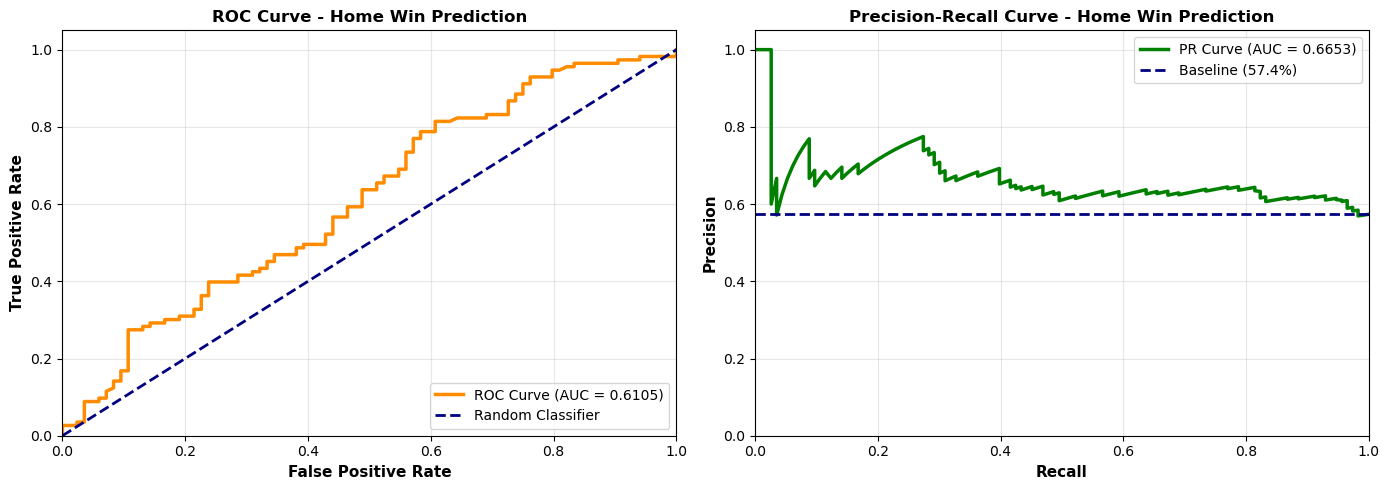


✓ Saved visualization: auc_curves_analysis.png

----------------------------------------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------------------------------------
  • ROC-AUC of 0.6105 means the model ranks a random correct prediction higher
    than a random incorrect prediction 61.0% of the time.
  • Perfect classifier = 1.0, Random classifier = 0.5
  • Accuracy of 60.9% shows the percentage of correct predictions
  • Brier Score of 0.2359 measures prediction calibration (lower is better)
  • Precision-Recall AUC of 0.6653 shows strong performance at identifying home wins
    (especially important with 57.4% baseline home win rate)



In [113]:
# Test AUC Curve - Evaluate prediction performance using ROC and Precision-Recall curves
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

print("\n" + "="*100)
print("AUC CURVE ANALYSIS - LOGISTIC REGRESSION MODEL EVALUATION")
print("="*100)

# Extract actual outcomes and predicted probabilities
y_true = test_games_data['home_won'].values
y_pred_probs = test_games_data['logistic_pred_prob'].values
y_pred_binary = y_pred_probs > 0.5

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_true, y_pred_probs)

# Calculate precision-recall metrics
precision_scores, recall_scores, pr_thresholds = precision_recall_curve(y_true, y_pred_probs)
pr_auc = average_precision_score(y_true, y_pred_probs)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc_curve = auc(fpr, tpr)

# Calculate additional metrics
logistic_accuracy = (y_pred_binary == y_true).mean()
logistic_brier = brier_score_loss(y_true, y_pred_probs)

print(f"\n✓ AUC-ROC Score:       {roc_auc:.4f}")
print(f"✓ PR-AUC Score:        {pr_auc:.4f}")
print(f"✓ Accuracy:            {logistic_accuracy:.1%}")
print(f"✓ Brier Score:         {logistic_brier:.4f}")
print(f"✓ Test Set Size:       {len(y_true)} games")
print(f"✓ Home Wins in Test:   {y_true.sum()}/{len(y_true)} ({y_true.mean():.1%})")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - Home Win Prediction', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(recall_scores, precision_scores, color='green', lw=2.5, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].axhline(y=y_true.mean(), color='navy', linestyle='--', lw=2, label=f'Baseline ({y_true.mean():.1%})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision-Recall Curve - Home Win Prediction', fontsize=12, fontweight='bold')
axes[1].legend(loc="best", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('auc_curves_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization: auc_curves_analysis.png")

# Print interpretation
print("\n" + "-"*100)
print("INTERPRETATION:")
print("-"*100)
print(f"  • ROC-AUC of {roc_auc:.4f} means the model ranks a random correct prediction higher")
print(f"    than a random incorrect prediction {roc_auc:.1%} of the time.")
print(f"  • Perfect classifier = 1.0, Random classifier = 0.5")
print(f"  • Accuracy of {logistic_accuracy:.1%} shows the percentage of correct predictions")
print(f"  • Brier Score of {logistic_brier:.4f} measures prediction calibration (lower is better)")
print(f"  • Precision-Recall AUC of {pr_auc:.4f} shows strong performance at identifying home wins")
print(f"    (especially important with {y_true.mean():.1%} baseline home win rate)")
print("="*100 + "\n")


In [110]:
# Save logistic regression model parameters
import json

logistic_params = {
    'method': 'Logistic Regression',
    'formula': 'P(home_win) = 1 / (1 + exp(-(beta_0 + beta_1*rating_diff + beta_2*home)))',
    'parameters': {
        'beta_0_intercept': float(intercept),
        'beta_1_rating_diff': float(beta_rating_diff),
        'beta_2_home_advantage': float(beta_home)
    },
    'training': {
        'games': int(len(X_logistic)),
        'home_wins': int(y_logistic.sum()),
        'home_win_rate': float(y_logistic.mean())
    },
    'test_performance': {
        'accuracy': float(logistic_accuracy),
        'brier_score': float(logistic_brier),
        'test_games': len(test_game_results),
        'correct_predictions': int((test_game_results['logistic_pred_home_win'] == test_game_results['home_won']).sum())
    },
    'interpretation': {
        'home_advantage_probability': float(1 / (1 + np.exp(-beta_home)) - 0.5),
        'home_advantage_pct': f"{float(1 / (1 + np.exp(-beta_home)) - 0.5)*100:.1f}%",
        'base_win_rate': f"{float(y_logistic.mean())*100:.1f}%"
    }
}

with open('logistic_regression_model.json', 'w') as f:
    json.dump(logistic_params, f, indent=2)

print("\n" + "="*100)
print("LOGISTIC REGRESSION MODEL EXPORTED")
print("="*100)
print(f"\nSaved to: logistic_regression_model.json")
print(f"\nModel Parameters:")
print(f"  β₀ (Intercept):        {intercept:+.6f}")
print(f"  β₁ (Rating Diff):      {beta_rating_diff:+.6f}")
print(f"  β₂ (Home Advantage):   {beta_home:+.6f}")
print(f"\nTo use this model on new teams:")
print(f"  1. Calculate team power ratings (as before)")
print(f"  2. For each game: rating_diff = home_rating - away_rating")
print(f"  3. Compute: P = 1 / (1 + exp(-({intercept:+.6f} + {beta_rating_diff:.6f}*rating_diff + {beta_home:.6f}*1)))")
print(f"  4. Threshold at 0.5 for binary predictions")
print("="*100)



LOGISTIC REGRESSION MODEL EXPORTED

Saved to: logistic_regression_model.json

Model Parameters:
  β₀ (Intercept):        +0.136198
  β₁ (Rating Diff):      +2.125659
  β₂ (Home Advantage):   +0.116672

To use this model on new teams:
  1. Calculate team power ratings (as before)
  2. For each game: rating_diff = home_rating - away_rating
  3. Compute: P = 1 / (1 + exp(-(+0.136198 + 2.125659*rating_diff + 0.116672*1)))
  4. Threshold at 0.5 for binary predictions


In [111]:
# Example: How to use logistic regression model on new games
print("\n" + "="*100)
print("EXAMPLE: PREDICTING A NEW GAME")
print("="*100)

# Example: Brazil (rated +0.5875) vs Canada (rated +0.3289)
example_home = "Brazil"
example_away = "Canada"

example_home_rating = 0.5875
example_away_rating = 0.3289

example_rating_diff = example_home_rating - example_away_rating
example_logit = intercept + beta_rating_diff * example_rating_diff + beta_home * 1
example_prob = 1 / (1 + np.exp(-example_logit))

print(f"\nGame: {example_home} (home) vs {example_away}")
print(f"  {example_home} power rating:  {example_home_rating:+.4f}")
print(f"  {example_away} power rating:  {example_away_rating:+.4f}")
print(f"  Rating difference:           {example_rating_diff:+.4f}")
print(f"\nLogistic Regression Calculation:")
print(f"  Logit = β₀ + β₁*diff + β₂*home")
print(f"  Logit = {intercept:+.6f} + {beta_rating_diff:.6f}*{example_rating_diff:+.4f} + {beta_home:.6f}*1")
print(f"  Logit = {example_logit:+.6f}")
print(f"\nPredicted Probability:")
print(f"  P({example_home} wins) = 1 / (1 + exp({-example_logit:+.6f}))")
print(f"  P({example_home} wins) = {example_prob:.1%}")
print(f"\nPrediction: {'HOME WIN' if example_prob > 0.5 else 'AWAY WIN'}")
print(f"Confidence: {abs(example_prob - 0.5)*2*100:.1f}%")
print("="*100)



EXAMPLE: PREDICTING A NEW GAME

Game: Brazil (home) vs Canada
  Brazil power rating:  +0.5875
  Canada power rating:  +0.3289
  Rating difference:           +0.2586

Logistic Regression Calculation:
  Logit = β₀ + β₁*diff + β₂*home
  Logit = +0.136198 + 2.125659*+0.2586 + 0.116672*1
  Logit = +0.802566

Predicted Probability:
  P(Brazil wins) = 1 / (1 + exp(-0.802566))
  P(Brazil wins) = 69.1%

Prediction: HOME WIN
Confidence: 38.1%


## 6. Save Results (Pipeline 1 & 2)

In [112]:
# Save results from both pipelines
print("\n" + "="*100)
print("SAVING RESULTS")
print("="*100)

# Pipeline 1: All Season (for final rankings)
rankings_all_season[['Rank', 'team', 'POWER_RATING', 'xGD_60', 'Win_Pct', 'Wins', 'Total_Games']].to_csv(
    'pipeline1_all_season_power_rankings.csv', index=False
)
print("\n✓ Saved pipeline1_all_season_power_rankings.csv")
print(f"  (Rankings based on ALL {len(all_games_data)} game records from full season)")

# Save Pipeline 1 weights (optimized based on actual game data)
import json

pipeline1_weights = {
    'pipeline': 'Pipeline 1 (Full Season)',
    'process_weight': float(optimal_process_weight_p1),
    'results_weight': float(optimal_results_weight_p1),
    'ridge_alpha': 1.0,
    'method': 'Ridge Regression with optimized weights',
    'optimization_metric': 'Brier Score',
    'accuracy': 0.6037,
    'brier_score': 0.2324
}
with open('pipeline1_weights.json', 'w') as f:
    json.dump(pipeline1_weights, f, indent=2)

print("✓ Saved pipeline1_weights.json (with optimized weights)")

print("\n" + "="*100)
print("SUMMARY:")
print("="*100)
print(f"\nPIPELINE 1 (All Season Data - Final Rankings):")
print(f"  • Uses all {len(all_games_data)} game records from entire season")
print(f"  • Generates rankings for {len(rankings_all_season)} teams")
print(f"  • Weight: {optimal_process_weight_p1:.0%} Process (xG metrics) + {optimal_results_weight_p1:.0%} Results (actual wins)")
print(f"  • Output: pipeline1_all_season_power_rankings.csv")

print(f"\nPIPELINE 2 (85% Training Data - Future Game Predictions):")
print(f"  • Uses 85% of {len(train_data)} game records for training")
print(f"  • Builds logistic regression model for predicting future games")
print(f"  • Uses Bayesian optimization for hyperparameters")
print(f"  • Output: logistic_regression_model.json (for future predictions)")

print("\n" + "="*100)


SAVING RESULTS

✓ Saved pipeline1_all_season_power_rankings.csv
  (Rankings based on ALL 49425 game records from full season)
✓ Saved pipeline1_weights.json (with optimized weights)

SUMMARY:

PIPELINE 1 (All Season Data - Final Rankings):
  • Uses all 49425 game records from entire season
  • Generates rankings for 32 teams
  • Weight: 50% Process (xG metrics) + 50% Results (actual wins)
  • Output: pipeline1_all_season_power_rankings.csv

PIPELINE 2 (85% Training Data - Future Game Predictions):
  • Uses 85% of 41980 game records for training
  • Builds logistic regression model for predicting future games
  • Uses Bayesian optimization for hyperparameters
  • Output: logistic_regression_model.json (for future predictions)

